# Desempleo vs Morosidad 90+(%) Consumo.

Autor: Arturo Díaz  
Fecha: Junio 2026  
Objetivo: Determinar si la tasa de desempleo puede ser un predictor de la mora 90+(%) consumo.

## I - Introducción

Una de las principales preocupaciones de las gerencias de riesgo de la banca es anticipar cambios en la tendencia de la morosidad para poder hacer ajustes anticipados en sus políticas de riesgo, y en este sentido mirar indicadores macroeconómicos puede dar luces de cambios futuros en la morosidad. Pero ¿de verdad estos indicadores están relacionados? Y de ser así, ¿es posible inferir en qué grado afectan a la morosidad?
Este estudio busca encontrar si existe una relación entre la tasa de desempleo y la mora 90+(%) consumo, para que en una posterior etapa se puedan desarrollar modelos que permitan determinar en cuántos meses un cambio en el desempleo puede afectar a la mora 90+(%).

## II - Metodología

En esta primera parte se determinará si existe una relación, no espuria, entre desempleo y morosidad consumo 90+(%). Para ello se seguirán los siguientes pasos:

* Descarga de datos de desempleo desde la API pública de https://mindicador.cl/ y datos de morosidad consumo 90+(%) mediante web scraping desde el sitio https://www.best-cmf.cl/.
* Análisis exploratorio de datos que nos dé luces de una posible relación entre desempleo y morosidad, detectar tendencias y efectos de la pandemia sobre nuestras series de tiempo.
* Pruebas de estacionariedad mediante los tests ADF y KPSS.
* Prueba de cointegración mediante los tests Engle-Granger y Gregory-Hansen.
* Cálculo de elasticidad a largo plazo.
* Conclusiones finales.

Antes de cerrar la metodología es importante mencionar que los shocks de la pandemia, tanto para el desempleo como para la morosidad (producto del exceso de liquidez por las medidas gubernamentales y los retiros de fondos de las AFP), presentan un desafío adicional que es necesario controlar para evitar que dichos shocks nos den conclusiones equivocadas.

## 1 - Carga de librerías

In [1]:
import requests
import pandas as pd
import numpy as np
import json
from time import sleep
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm


## 2 - Descarga de datos

In [2]:
# Descargameos los datos de desempleo desde el API de mindicador.cl
all_rows = []

for year in range(2014, 2027):  # ajusta el límite superior si quieres
    url = f"https://mindicador.cl/api/tasa_desempleo/{year}"
    r = requests.get(url, timeout=90)
    
    if r.status_code == 200:
        data = r.json()
        if "serie" in data:
            for row in data["serie"]:
                all_rows.append({
                    "fecha": row["fecha"],
                    "desempleo": row["valor"]
                })
    sleep(0.2)

df = pd.DataFrame(all_rows)
df["fecha"] = pd.to_datetime(df["fecha"])
df["desempleo"] = pd.to_numeric(df["desempleo"], errors="coerce")
df = df.sort_values("fecha").drop_duplicates()


df["fecha_cruce"] = df["fecha"].dt.year*10000 + df["fecha"].dt.month*100 + 1

display(df.head())

# Descargamos los datos de mora 90+ del sistema bancario mediante web scraping del sitio best-cmf.c
url = "https://best-sbif-api.azurewebsites.net/Cuadrosv2?FechaFin=20260401&FechaInicio=20090101&Tag=CMF_CONT_MOR_90DMAS_CONSOL_STO_RAZ_PORC_MONT&from=reload"
r = requests.get(url)
r.raise_for_status()
data = r.json()

# Primero hacemos un diccionario  
Desc_series = []
for i in data["series"]:
    codigo=(i["codigo"])
    descripcion=(i["descripcionCorta"])
    Desc_series.append({"codigo": codigo, "descripcion": descripcion})

Desc_series = pd.DataFrame(Desc_series)

datos_mora = []
for  j in data["series"]:
        mora = j["codigo"]

        for i in j["observaciones"]:
            fecha = i["fecha"]
            valor = i["valor"]
            datos_mora.append({"codigo": mora, "fecha": fecha, "valor": valor})

mora_banca = pd.DataFrame(datos_mora)

display(Desc_series.head())

display(mora_banca.head())

codigos = [
    #"CMF_CONT_MOR_90DMAS_CONSOL_CHV_STO_RAZ_PORC_MONT",
    "CMF_CONT_MOR_90DMAS_CONSOL_CCS_STO_RAZ_PORC_MONT"#,
    #"CMF_CONT_MOR_90DMAS_CONSOL_PER_STO_RAZ_PORC_MONT"
]

mora_pivot = (
    mora_banca[mora_banca["codigo"].isin(codigos)]
    .pivot_table(index="fecha", columns="codigo", values="valor", aggfunc="first")
    .reset_index()
)

mora_pivot = mora_pivot.rename(columns={
    #"CMF_CONT_MOR_90DMAS_CONSOL_CHV_STO_RAZ_PORC_MONT": "Vivienda",
    "CMF_CONT_MOR_90DMAS_CONSOL_CCS_STO_RAZ_PORC_MONT": "Consumo"#,
    #"CMF_CONT_MOR_90DMAS_CONSOL_PER_STO_RAZ_PORC_MONT": "Personas"
})





mora_pivot = mora_pivot.merge(
    df[["fecha_cruce", "desempleo"]],
    left_on="fecha",
    right_on="fecha_cruce",
    how="left"
)

mora_pivot["fecha2"] = pd.to_datetime(mora_pivot["fecha"].astype(str), format="%Y%m%d")

display(mora_pivot)

,fecha,desempleo,fecha_cruce
11,2014-01-01 03:00:00+00:00,6.1,20140101
10,2014-02-01 03:00:00+00:00,6.1,20140201
9,2014-03-01 03:00:00+00:00,6.5,20140301
8,2014-04-01 03:00:00+00:00,6.1,20140401
7,2014-05-01 04:00:00+00:00,6.3,20140501


,codigo,descripcion
0,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...
1,CMF_CONT_MOR_90DMAS_CONSOL_CCA_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...
2,CMF_CONT_MOR_90DMAS_CONSOL_CCO_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...
3,CMF_CONT_MOR_90DMAS_CONSOL_PER_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...
4,CMF_CONT_MOR_90DMAS_CONSOL_CCS_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...


,codigo,fecha,valor
0,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20210301,1.554919
1,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20230601,1.935510
2,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20210101,1.543865
3,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20220601,1.405594
4,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20161101,1.888599


,fecha,Consumo,fecha_cruce,desempleo,fecha2
0,20140301,2.088224,20140301,6.50,2014-03-01
1,20140401,2.089532,20140401,6.10,2014-04-01
2,20140501,2.078027,20140501,6.30,2014-05-01
3,20140601,2.080219,20140601,6.50,2014-06-01
4,20140701,2.087967,20140701,6.50,2014-07-01
...,...,...,...,...,...
141,20251201,2.621626,20251201,8.05,2025-12-01
142,20260101,2.579598,20260101,8.28,2026-01-01
143,20260201,2.599583,20260201,8.33,2026-02-01
144,20260301,2.446283,20260301,8.93,2026-03-01


In [3]:
#desestacionalizamos las series que usaremos

res_consumo = seasonal_decompose(
    mora_pivot["Consumo"],
    model="additive",
    period=12
)

res_desempleo = seasonal_decompose(
    mora_pivot["desempleo"],
    model="additive",
    period=12
)

mora_pivot["Consumo_sa"]   = res_consumo.observed.values - res_consumo.seasonal.values
mora_pivot["desempleo_sa"] = res_desempleo.observed.values - res_desempleo.seasonal.values

display(mora_pivot)

,fecha,Consumo,fecha_cruce,desempleo,fecha2,Consumo_sa,desempleo_sa
0,20140301,2.088224,20140301,6.50,2014-03-01,2.071837,6.546927
1,20140401,2.089532,20140401,6.10,2014-04-01,2.062642,6.122003
2,20140501,2.078027,20140501,6.30,2014-05-01,2.026280,6.016738
3,20140601,2.080219,20140601,6.50,2014-06-01,2.038500,6.167836
4,20140701,2.087967,20140701,6.50,2014-07-01,2.064393,6.080753
...,...,...,...,...,...,...,...
141,20251201,2.621626,20251201,8.05,2025-12-01,2.642225,8.545260
142,20260101,2.579598,20260101,8.28,2026-01-01,2.557212,8.697192
143,20260201,2.599583,20260201,8.33,2026-02-01,2.527433,8.605298
144,20260301,2.446283,20260301,8.93,2026-03-01,2.429897,8.976927


# 3 - EDA

En primer lugar analizamos las tendencias de ambas series, observando visualmente sus componentes desestacionalizados.

In [4]:

def graficos_tendencia(tabla,fecha_var, serie_var, titulo_var):

    fig = px.line(tabla, x = fecha_var, y = serie_var, title = f"{titulo_var} a lo largo del tiempo")
    fig.show()

    serie = (tabla.sort_values(fecha_var)
            .drop_duplicates(fecha_var)
            .set_index(fecha_var)[serie_var]
            .asfreq("MS")
            .interpolate(method="time"))   # rellena los NaN respetando el espaciado temporal

    res = STL(serie, period=12).fit()
    fig = res.plot()
    fig.suptitle(f"Descomposición STL de {titulo_var}", fontsize=13, fontweight="bold") 
    fig.set_size_inches(10, 8)
    plt.tight_layout()
    plt.show()


    resid = res.resid.dropna()
    plot_acf(resid, lags=36, title=f"ACF de los residuos de {titulo_var}")
    plt.show()

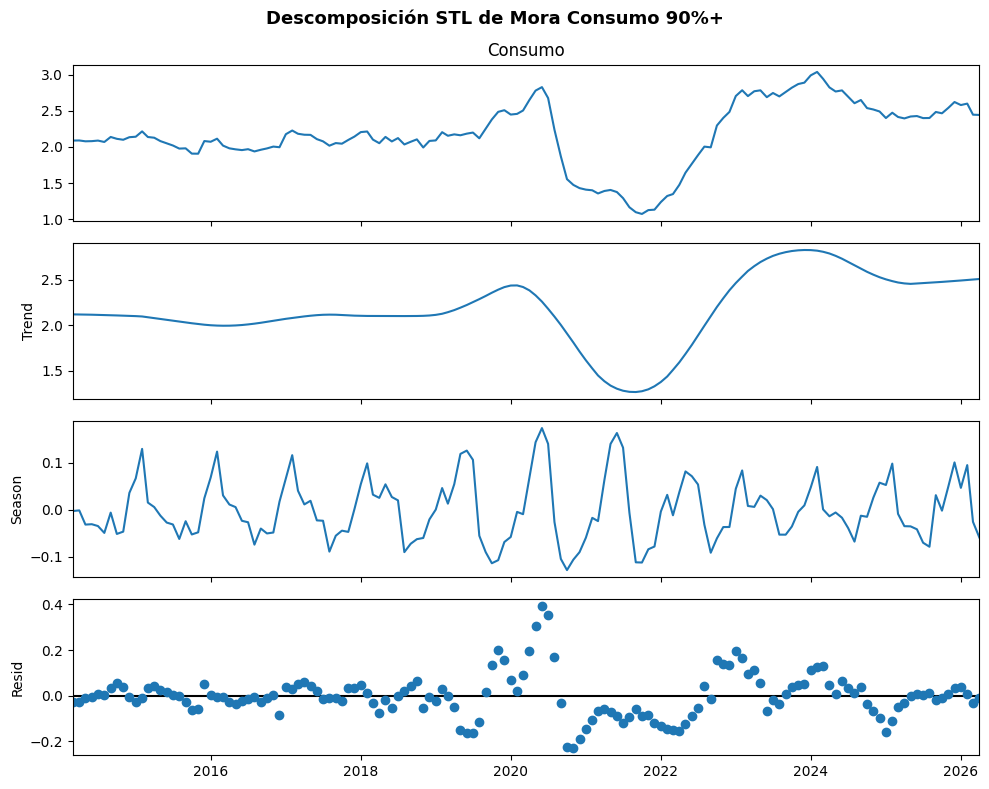

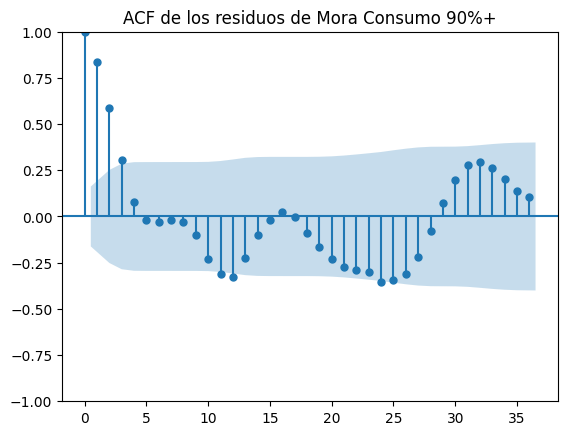

--------------------------------------------------------------------------------


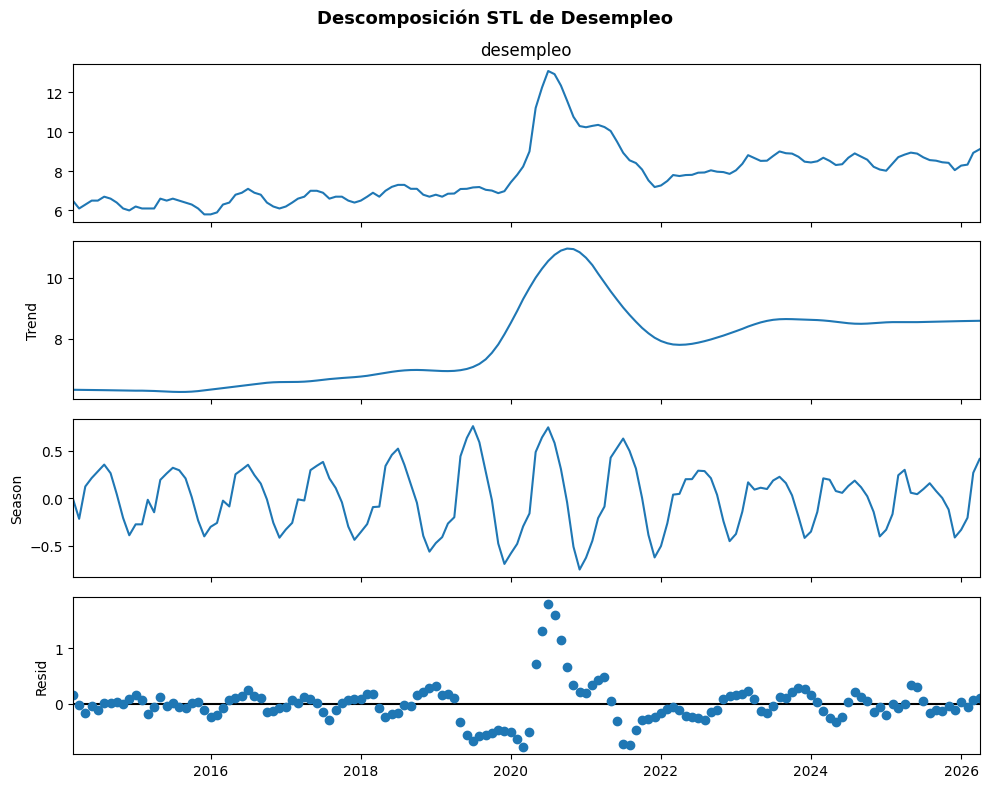

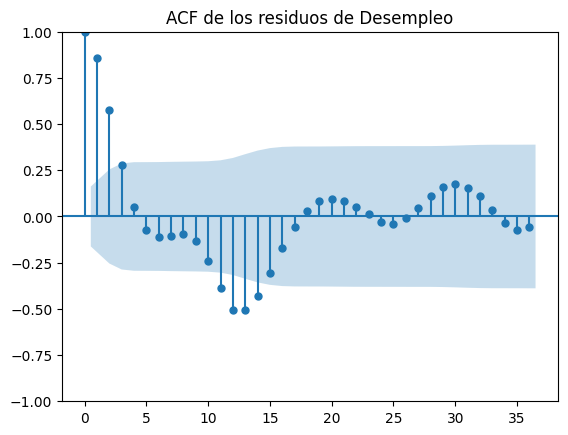

In [5]:
graficos_tendencia(mora_pivot,"fecha2", "Consumo", "Mora Consumo 90%+")
print(80*"-")
graficos_tendencia(mora_pivot,"fecha2", "desempleo", "Desempleo")

Se observa un efecto curioso y quizás contraintuitivo: durante el periodo de pandemia existió una alta tasa de desempleo, pero también una baja muy marcada en la morosidad 90+(%). Esto se explica por el exceso de liquidez de esa época (traspasos gubernamentales y retiros de fondos de las AFP). Dado lo anterior, es importante mirar con especial detalle cómo esos valores anómalos afectan a nuestros datos; en los gráficos de desestacionalización de nuestras series observamos que esos shocks incluso se ven reflejados en los residuos.
A continuación buscaremos los candidatos a correlación y, dado que se detectaron datos anómalos durante el periodo de pandemia, se analizarán correlaciones para la serie completa, la serie con pandemia omitida y la serie post pandemia.

In [6]:
max_lag = 24

corrs = []
for k in range(max_lag + 1):
    corr = mora_pivot["Consumo"].corr(mora_pivot["desempleo"].shift(k))
    corrs.append((k, corr))

corrs_sa = []
for k in range(max_lag + 1):
    corr = mora_pivot["Consumo_sa"].corr(mora_pivot["desempleo_sa"].shift(k))
    corrs_sa.append((k, corr))

correlaciones    = pd.DataFrame(corrs, columns=["lag", "correlacion"])
correlaciones_sa = pd.DataFrame(corrs_sa, columns=["lag", "correlacion"])

correlaciones    = pd.DataFrame(corrs,    columns=["lag", "correlacion"])
correlaciones_sa = pd.DataFrame(corrs_sa, columns=["lag", "correlacion_sa"])  # ← nombre distinto desde el inicio

correlaciones = correlaciones.merge(
    correlaciones_sa,
    on="lag",
    how="left"
)
correlaciones.head()



,lag,correlacion,correlacion_sa
0,0,0.105830,0.113216
1,1,0.021471,0.036173
2,2,-0.062806,-0.045404
3,3,-0.136754,-0.122703
4,4,-0.193236,-0.187245


In [7]:
def busca_correlaciones(tabla, n_lags):
    max_lag = n_lags

    corrs = []
    for k in range(max_lag + 1):
        corr = tabla["Consumo"].corr(tabla["desempleo"].shift(k))
        corrs.append((k, corr))

    corrs_sa = []
    for k in range(max_lag + 1):
        corr = tabla["Consumo_sa"].corr(tabla["desempleo_sa"].shift(k))
        corrs_sa.append((k, corr))

    correlaciones = pd.DataFrame(corrs, columns=["lag", "correlacion"])
    correlaciones_sa = pd.DataFrame(corrs_sa, columns=["lag", "correlacion_sa"])

    correlaciones2 = correlaciones.merge(correlaciones_sa, on="lag", how="left")

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    # --- gráfico 1: series originales
    axes[0].plot(
        correlaciones2["lag"],
        correlaciones2["correlacion"],
        alpha=0.8,
        color="royalblue",
        marker="o",
        label="Mora Consumo 90+ vs Desempleo"
    )
    axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[0].set_title("Correlación Mora 90+% Consumo vs Desempleo (Series originales)")
    axes[0].set_ylabel("Correlación")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    # Etiquetas de cada punto
    for x, y in zip(correlaciones2["lag"], correlaciones2["correlacion"]):
        axes[0].annotate(
            f"{y:.2f}",
            xy=(x, y),
            xytext=(0, 6 if y >= 0 else -12),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="royalblue"
        )

    # --- gráfico 2: series desestacionalizadas
    axes[1].plot(
        correlaciones2["lag"],
        correlaciones2["correlacion_sa"],
        alpha=0.8,
        color="darkorange",
        marker="o",
        label="Mora Consumo 90+ SA vs Desempleo SA"
    )
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_title("Correlación Mora 90+% Consumo vs Desempleo (Series desestacionalizadas)")
    axes[1].set_ylabel("Correlación")
    axes[1].set_xlabel("Lag (meses)")
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    # Etiquetas de cada punto
    for x, y in zip(correlaciones2["lag"], correlaciones2["correlacion_sa"]):
        axes[1].annotate(
            f"{y:.2f}",
            xy=(x, y),
            xytext=(0, 6 if y >= 0 else -12),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="darkorange"
        )

    # Mostrar todos los puntos del eje X
    axes[1].set_xticks(correlaciones2["lag"])

    plt.tight_layout()
    plt.show()

    return correlaciones2

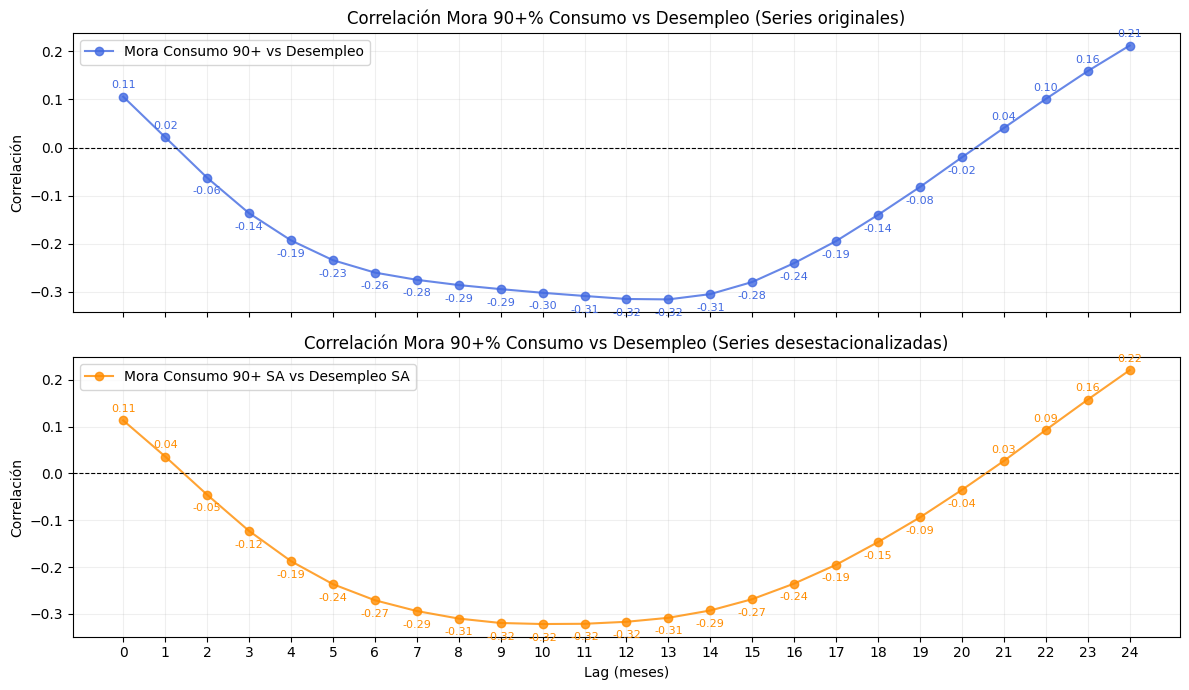

In [8]:
correlaciones2 = busca_correlaciones(mora_pivot, 24)

Esto último nos da una información un poco contradictoria: tanto el desempleo inmediato como el desempleo rezagado hasta 24 meses parecen influir en la morosidad de consumo, pero esto podría estar relacionado con los shocks que sufrieron tanto el desempleo como la morosidad durante la pandemia. Para tratar de aislar este efecto, analizaremos tramos que excluyan el periodo de pandemia.
En primer lugar se analiza la serie excluyendo el periodo de pandemia, y posteriormente la serie posterior a junio de 2023, donde termina el ciclo al alza de la mora 90+(%).

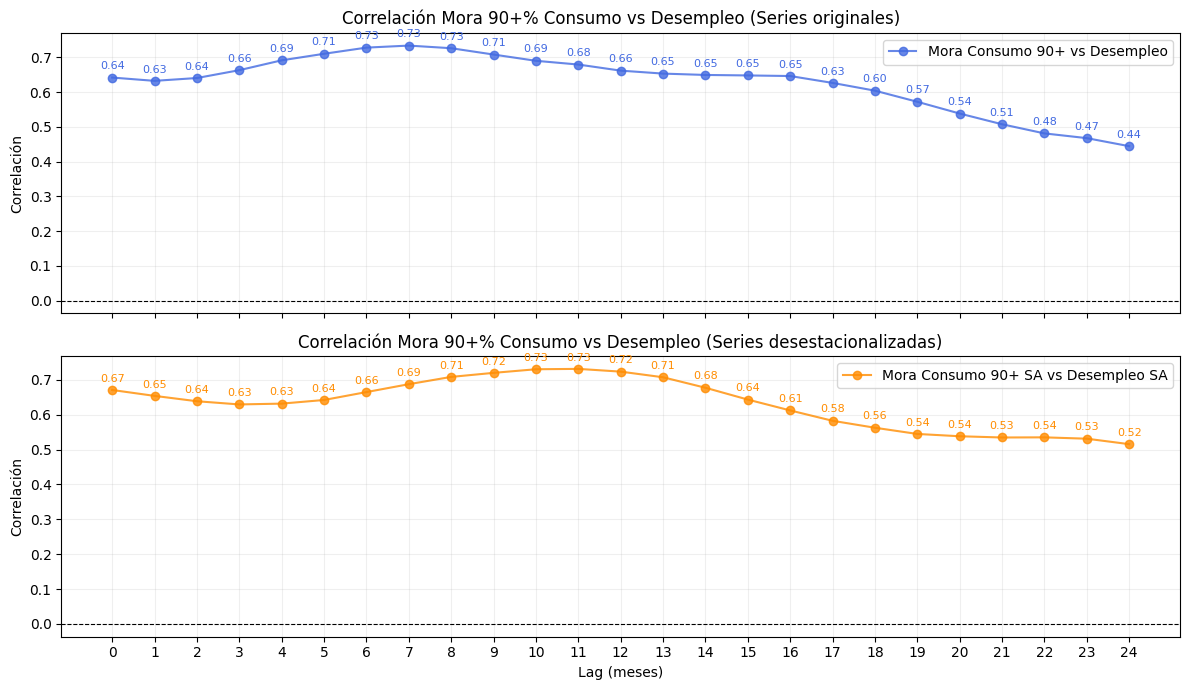

In [9]:
mora_sin_pandemia = mora_pivot[
    (mora_pivot["fecha2"] < "2020-03-01") | 
    (mora_pivot["fecha2"] > "2021-12-01")
].copy()
correlaciones2 = busca_correlaciones(mora_sin_pandemia, 24)

Al observar la serie omitiendo el periodo de pandemia se observa que los rezagos 7 al 13 presentan una alta correlación. A continuación se analiza la correlación posterior a junio 2023.

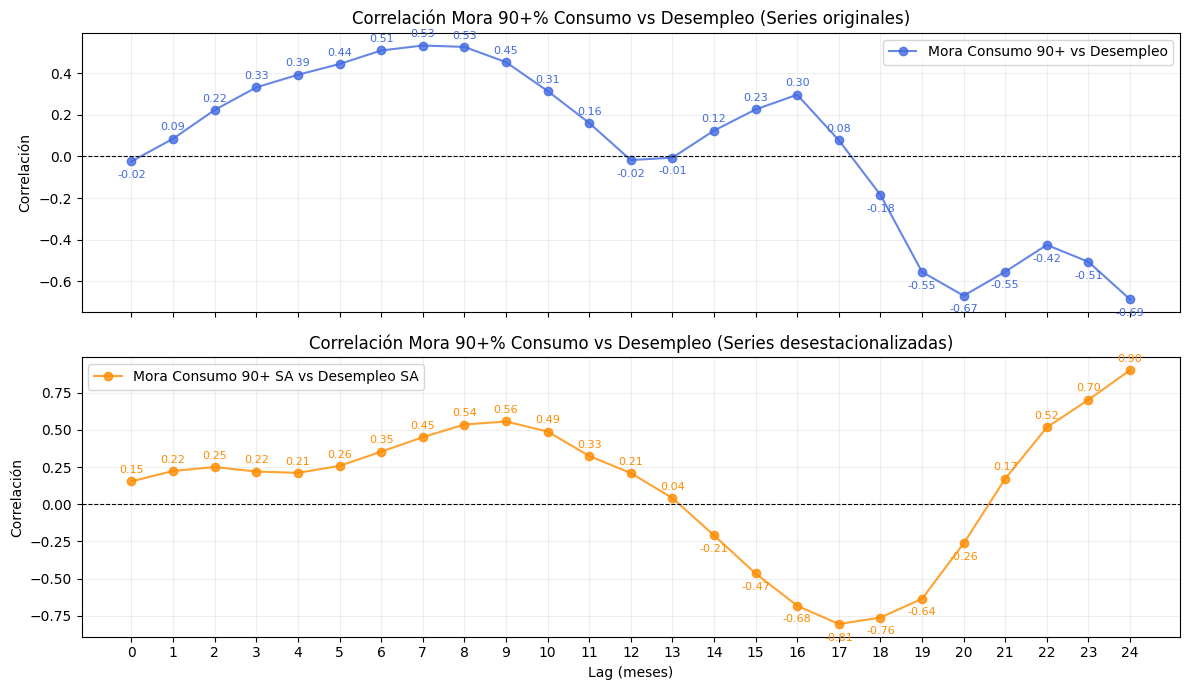

In [10]:

mora_post_pandemia = mora_pivot[mora_pivot["fecha2"] > "2023-06-01"].copy()
correlaciones2 = busca_correlaciones(mora_post_pandemia, 24)

Al analizar las correlaciones posteriores a junio 2023 se observa que los rezagos 7 al 13 siguen presentando alta correlación. Si bien a partir del rezago 18 parece haber una tendencia a aumentar la correlación, la escasa cantidad de registros provoca este resultado anómalo.
A continuación se analiza gráficamente la relación entre mora 90+(%) y los distintos rezagos que detectamos en los pasos anteriores.

In [11]:
def grafico_mora_vs_desempleo(tabla, n_lags):
    mora_plot = tabla.dropna(subset=["Consumo", "desempleo", "Consumo_sa", "desempleo_sa"]).copy()
    mora_plot["fecha2"] = pd.to_datetime(mora_plot["fecha2"]) 

    titulo = "Mora Consumo 90+ vs Desempleo" if n_lags == 0 else f"Mora Consumo 90+ vs Desempleo (Rezago de {n_lags} meses)"
    etiqueta_desmpleo = "Desempleo" if n_lags == 0 else f"Desempleo lag({n_lags})"
    etiqueta_desmpleo_sa = "Desempleo SA" if n_lags == 0 else f"Desempleo SA lag({n_lags})"




    fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
    fig.suptitle(
        titulo,
        fontsize=14,
        fontweight="bold",
        y=1.01
    )

    # -----------------------------
    # Panel 1: Series originales
    # -----------------------------
    ax1 = axes[0]
    ax1_r = ax1.twinx()

    ax1.plot(
        mora_plot["fecha2"],
        mora_plot["Consumo"],
        color="#1f77b4",
        linewidth=2,
        label="Mora Consumo 90+"
    )

    ax1_r.plot(
        mora_plot["fecha2"],
        mora_plot["desempleo"].shift(n_lags),
        color="#d62728",
        linewidth=1.8,
        linestyle="--",
        label=etiqueta_desmpleo
    )

    ax1.set_ylabel("Mora 90+ (%)", color="#1f77b4")
    ax1_r.set_ylabel("Desempleo (%)", color="#d62728")
    ax1.tick_params(axis="y", labelcolor="#1f77b4")
    ax1_r.tick_params(axis="y", labelcolor="#d62728")
    ax1.set_title("Series originales", fontsize=11)

    ax1.axvspan(
        pd.Timestamp("2020-03-01"),
        pd.Timestamp("2021-12-01"),
        alpha=0.1,
        color="gray",
        label="Liquidez extraordinaria"
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1_r.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
    ax1.grid(alpha=0.2)

    # -----------------------------
    # Panel 2: Series desestacionalizadas
    # -----------------------------
    ax2 = axes[1]
    ax2_r = ax2.twinx()

    ax2.plot(
        mora_plot["fecha2"],
        mora_plot["Consumo_sa"],
        color="#1f77b4",
        linewidth=2,
        label="Mora Consumo 90+ SA"
    )

    ax2_r.plot(
        mora_plot["fecha2"],
        mora_plot["desempleo_sa"].shift(n_lags),
        color="#d62728",
        linewidth=1.8,
        linestyle="--",
        label=etiqueta_desmpleo_sa
    )

    ax2.set_ylabel("Mora 90+ SA (%)", color="#1f77b4")
    ax2_r.set_ylabel("Desempleo SA (%)", color="#d62728")
    ax2.tick_params(axis="y", labelcolor="#1f77b4")
    ax2_r.tick_params(axis="y", labelcolor="#d62728")
    ax2.set_title("Series desestacionalizadas", fontsize=11)

    ax2.axvspan(
        pd.Timestamp("2020-03-01"),
        pd.Timestamp("2021-12-01"),
        alpha=0.1,
        color="gray",
        label="Liquidez extraordinaria"
    )

    lines3, labels3 = ax2.get_legend_handles_labels()
    lines4, labels4 = ax2_r.get_legend_handles_labels()
    ax2.legend(lines3 + lines4, labels3 + labels4, loc="upper left", fontsize=9)
    ax2.grid(alpha=0.2)

    ax2.xaxis.set_major_locator(mdates.YearLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.autofmt_xdate()

    plt.tight_layout()
    plt.show()

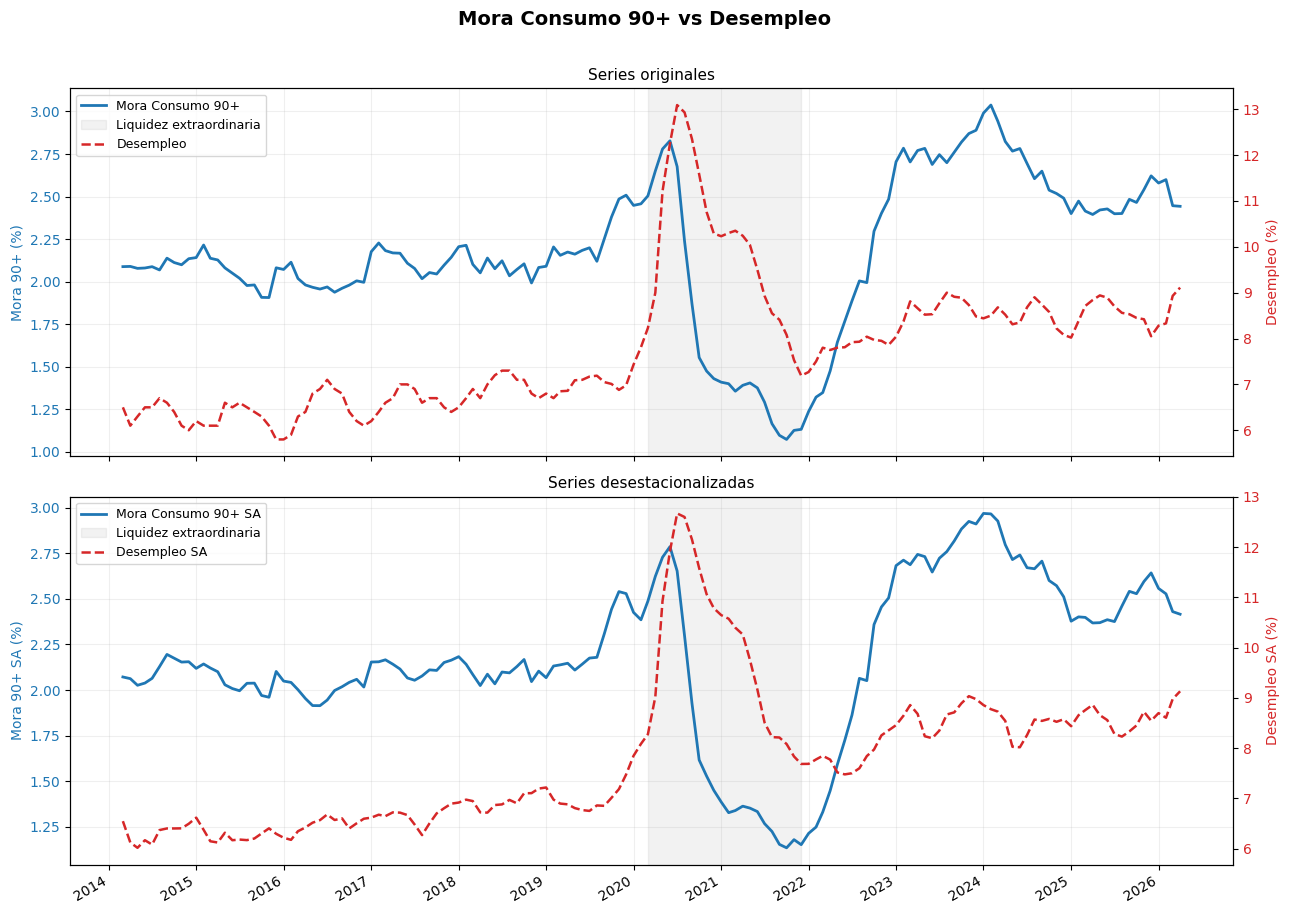

----------------------------------------------------------------------------------------------------


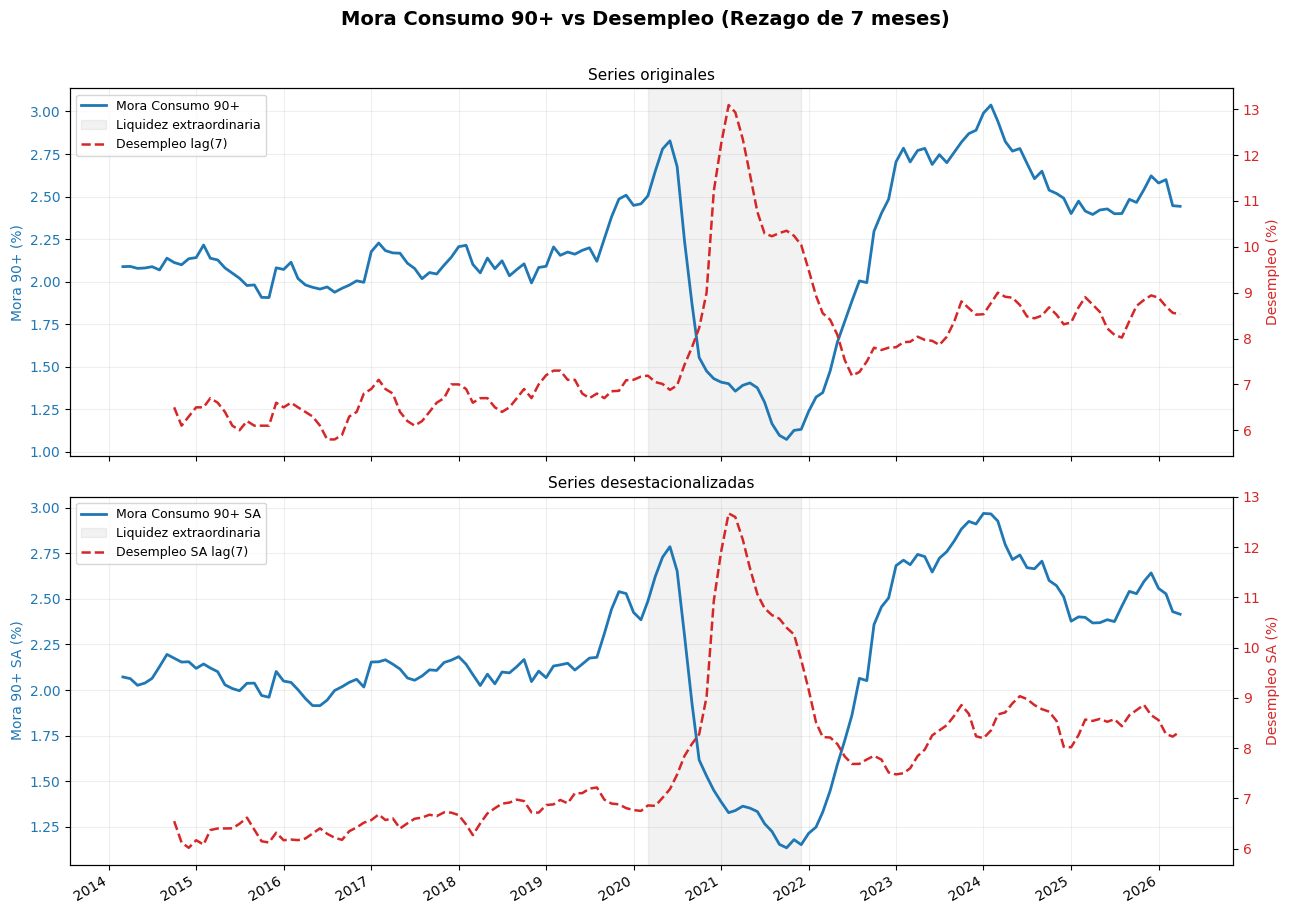

----------------------------------------------------------------------------------------------------


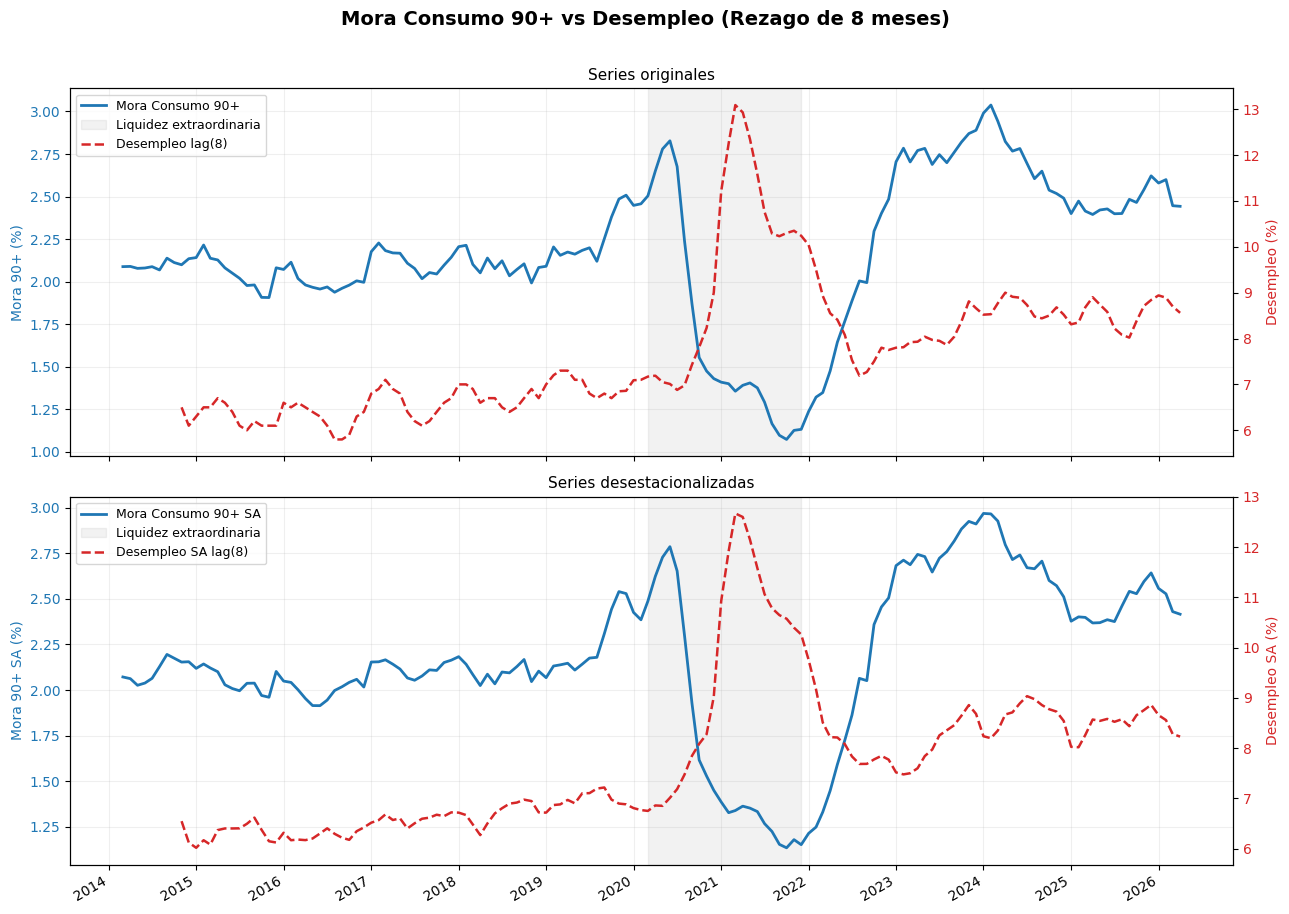

----------------------------------------------------------------------------------------------------


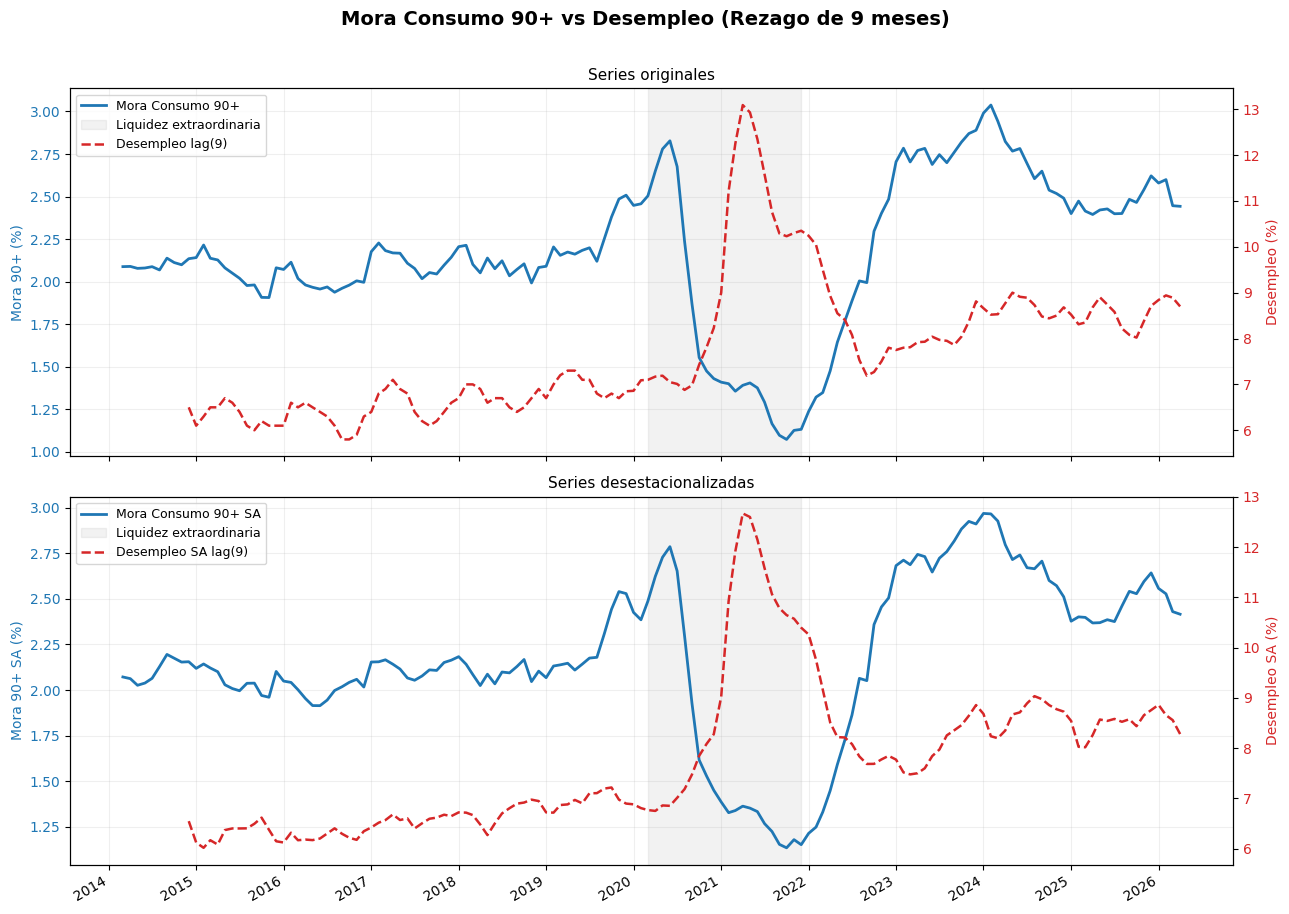

----------------------------------------------------------------------------------------------------


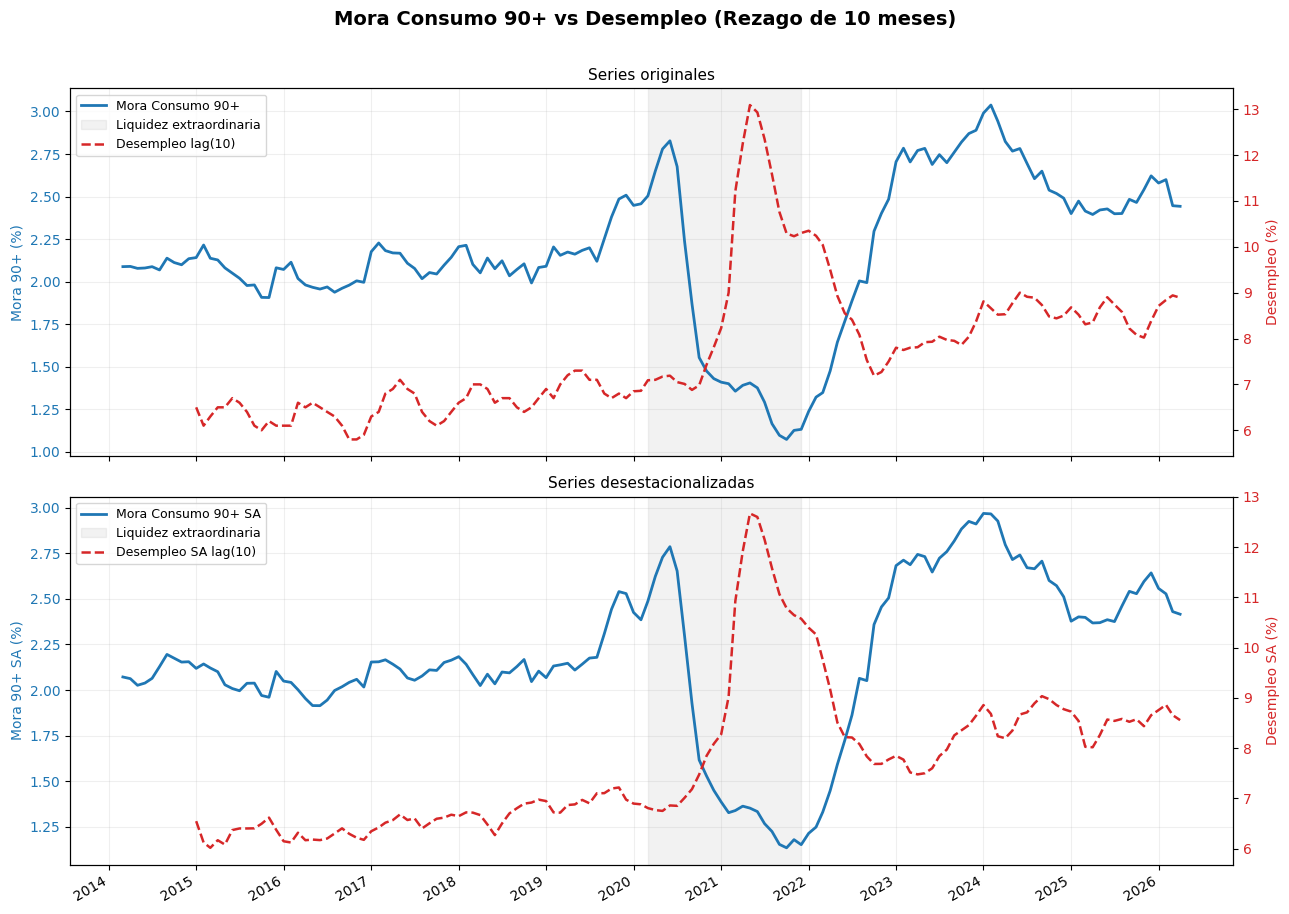

----------------------------------------------------------------------------------------------------


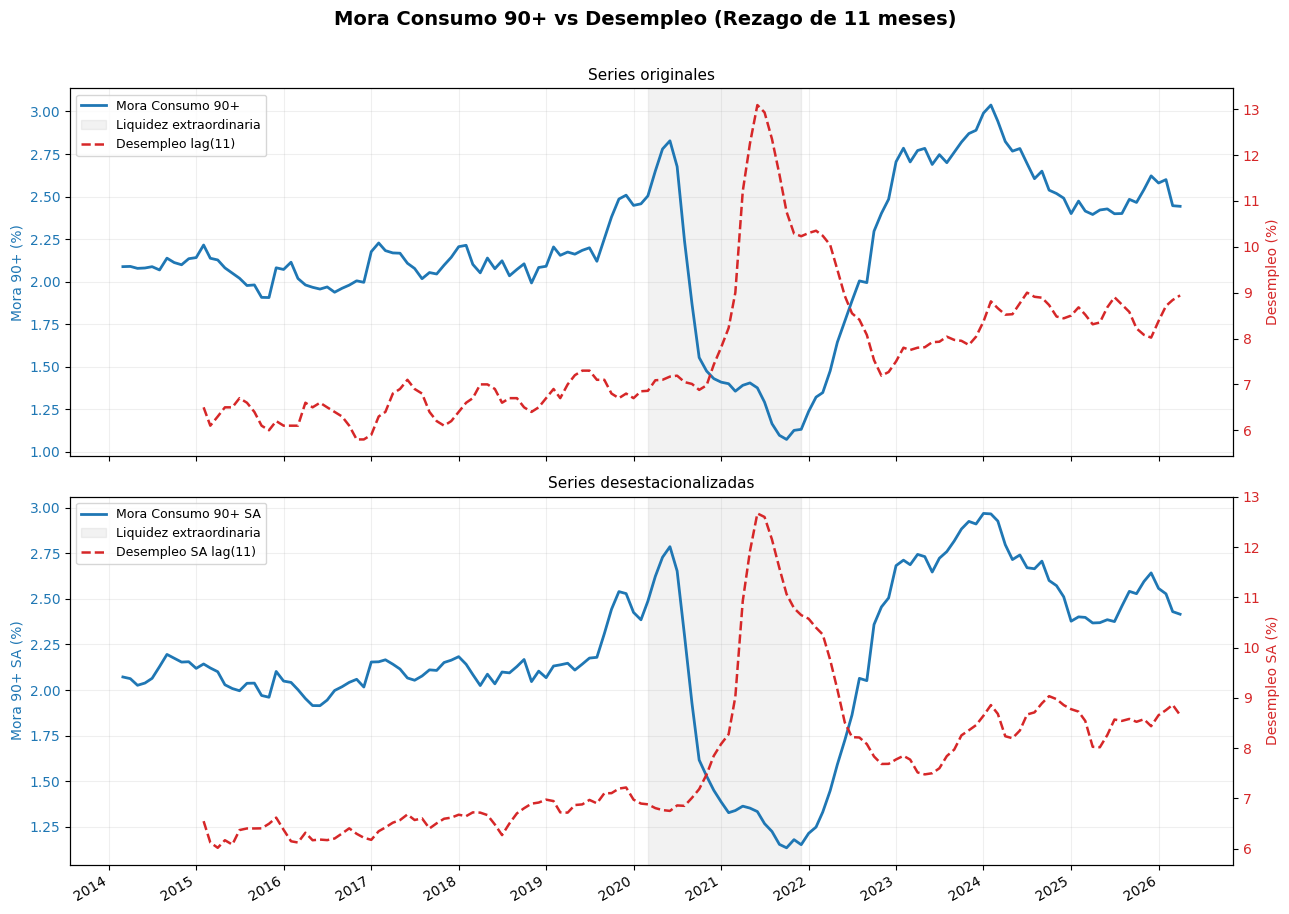

----------------------------------------------------------------------------------------------------


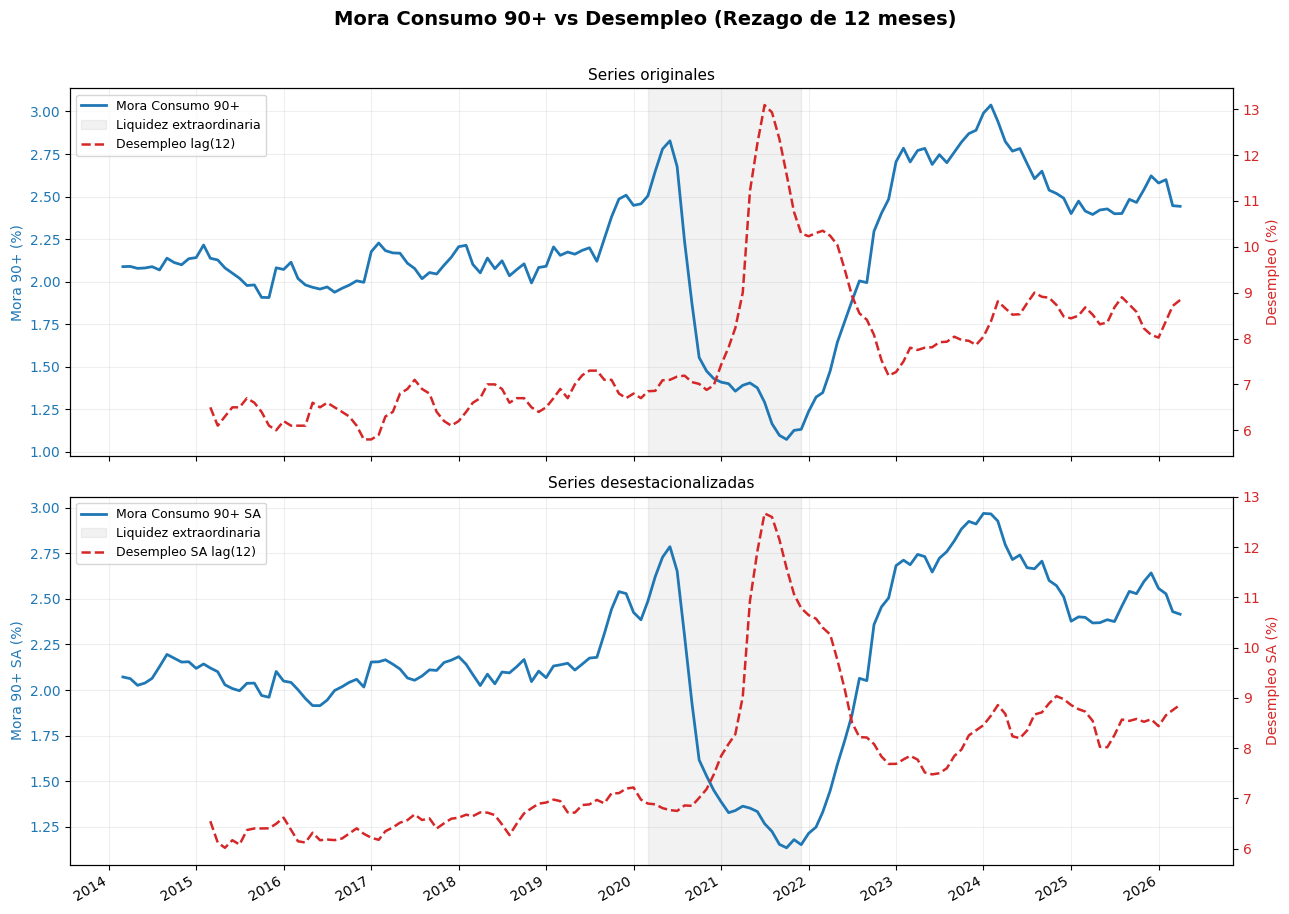

----------------------------------------------------------------------------------------------------


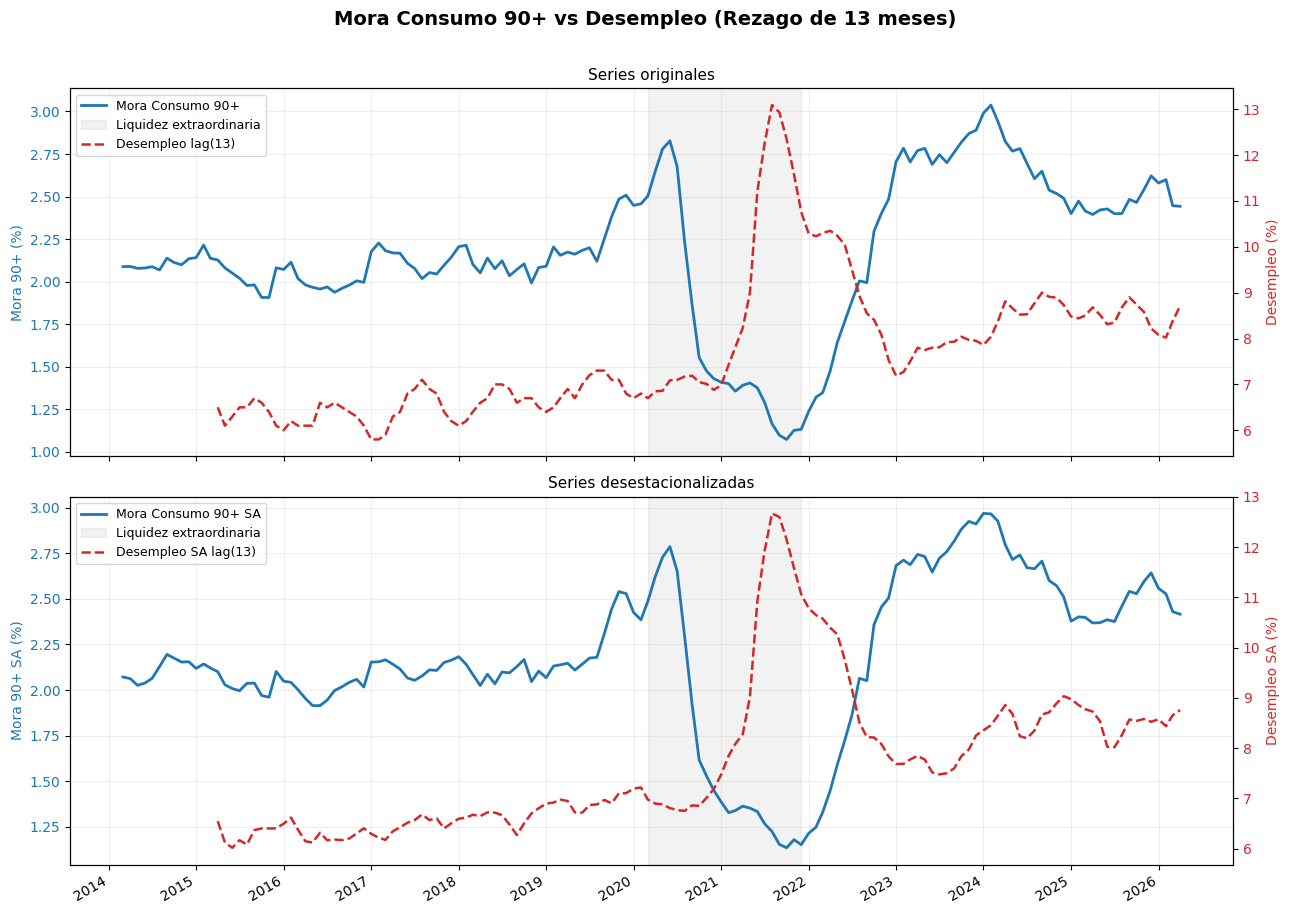

----------------------------------------------------------------------------------------------------


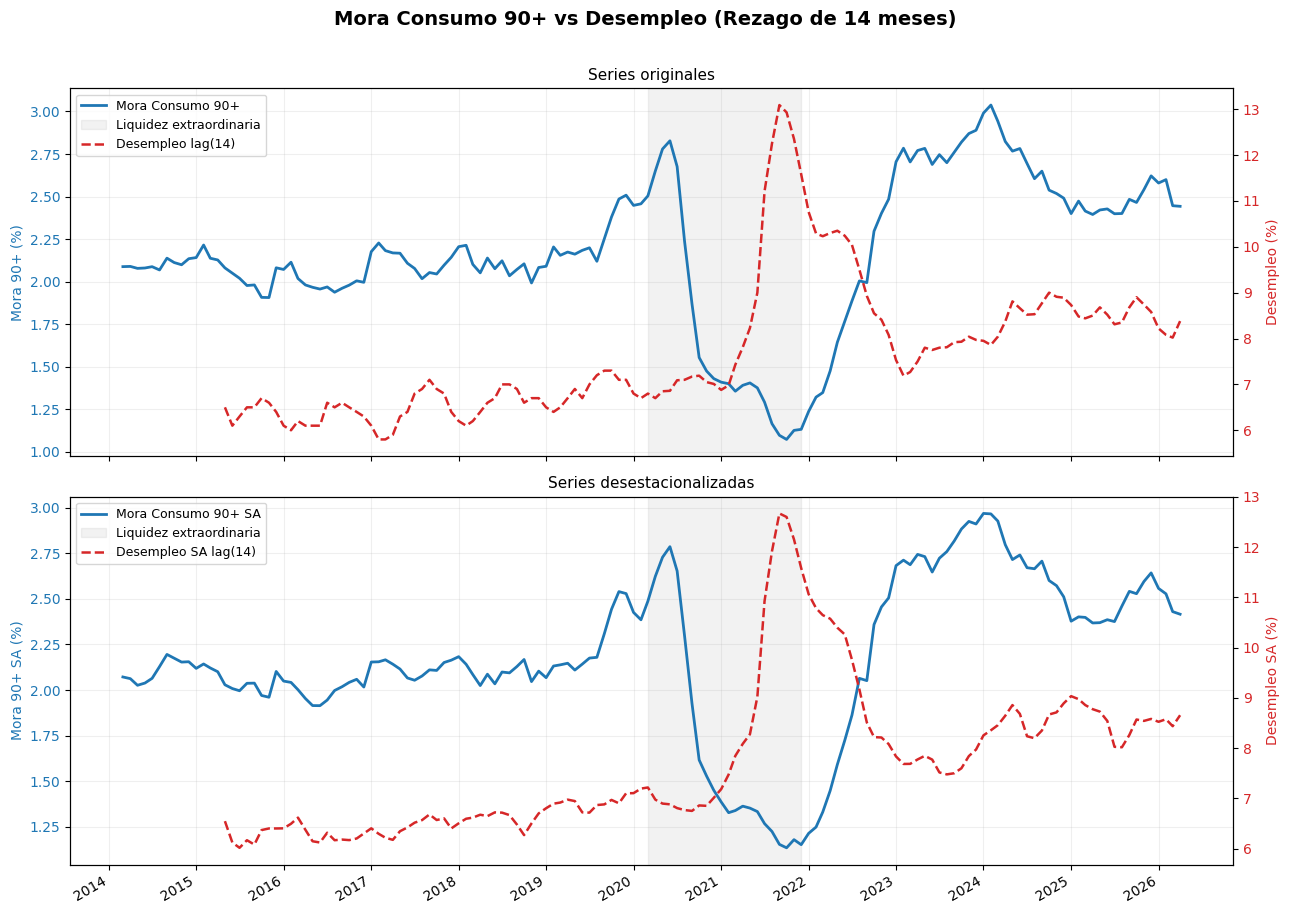

----------------------------------------------------------------------------------------------------


In [12]:
candidatos = [0,7,8,9,10,11,12,13, 14]

for i in candidatos:
    grafico_mora_vs_desempleo(mora_pivot, i)
    print(100*"-")

A simple vista parece haber una relación entre los rezagos 8 y 9, pero como ya hemos visto, los shocks de la pandemia pueden introducir cierto ruido que es importante considerar. A continuación se analiza la estacionariedad y cointegración entre ambas series.

# 4 - Estacionariedad

Para determinar la estacionariedad, aplicaremos los tests ADF y KPSS.

In [13]:
def test_estacionariedad(df, fecha_var, serie_var):
    serie = (df.sort_values(fecha_var)
               .drop_duplicates(fecha_var)
               .set_index(fecha_var)[serie_var]
               .asfreq("MS")
               .interpolate(method="time")
               .dropna())

    # ADF
    adf_result = adfuller(serie, autolag="AIC")
    adf_pval = adf_result[1]

    # KPSS
    kpss_result = kpss(serie, regression="ct", nlags="auto")
    kpss_pval = kpss_result[1]

    print(f"\n{'='*45}")
    print(f"Serie: {serie_var}")
    print(f"{'='*45}")
    print(f"ADF  p-value: {adf_pval:.4f}  → {'Estacionaria ✅' if adf_pval < 0.05 else 'No estacionaria ❌'}")
    print(f"KPSS p-value: {kpss_pval:.4f}  → {'Estacionaria ✅' if kpss_pval > 0.05 else 'No estacionaria ❌'}")

    if adf_pval < 0.05 and kpss_pval > 0.05:
        print("→ CONCLUSIÓN: Estacionaria (ambos coinciden) ✅")
    elif adf_pval > 0.05 and kpss_pval < 0.05:
        print("→ CONCLUSIÓN: No estacionaria, tiene raíz unitaria ❌")
    else:
        print("→ CONCLUSIÓN: Contradicción, considera diferenciar o revisar quiebres estructurales ⚠️")

In [14]:
# estacionaridad series sin rezago
test_estacionariedad(mora_pivot, "fecha2", "Consumo")
test_estacionariedad(mora_pivot, "fecha2", "desempleo")

test_estacionariedad(mora_pivot, "fecha2", "Consumo_sa")
test_estacionariedad(mora_pivot, "fecha2", "desempleo_sa")


Serie: Consumo
ADF  p-value: 0.0117  → Estacionaria ✅
KPSS p-value: 0.0800  → Estacionaria ✅
→ CONCLUSIÓN: Estacionaria (ambos coinciden) ✅

Serie: desempleo
ADF  p-value: 0.2924  → No estacionaria ❌
KPSS p-value: 0.0717  → Estacionaria ✅
→ CONCLUSIÓN: Contradicción, considera diferenciar o revisar quiebres estructurales ⚠️

Serie: Consumo_sa
ADF  p-value: 0.0609  → No estacionaria ❌
KPSS p-value: 0.0805  → Estacionaria ✅
→ CONCLUSIÓN: Contradicción, considera diferenciar o revisar quiebres estructurales ⚠️

Serie: desempleo_sa
ADF  p-value: 0.1823  → No estacionaria ❌
KPSS p-value: 0.0722  → Estacionaria ✅
→ CONCLUSIÓN: Contradicción, considera diferenciar o revisar quiebres estructurales ⚠️


Se obtiene como resultado que tanto la morosidad de consumo como el desempleo no presentan estacionariedad en nivel. El siguiente paso es evaluar ambas series diferenciadas en primer orden (d=1): si resultan estacionarias, confirmaríamos que ambas son integradas de orden 1 — I(1) —, condición necesaria para evaluar su cointegración.

In [15]:
# Series diferenciadas (d=1)
mora_pivot["Consumo_sa_d1"]   = mora_pivot["Consumo_sa"].diff()
mora_pivot["desempleo_sa_d1"] = mora_pivot["desempleo_sa"].diff()

test_estacionariedad(mora_pivot, "fecha2", "Consumo_sa_d1")
test_estacionariedad(mora_pivot, "fecha2", "desempleo_sa_d1")


Serie: Consumo_sa_d1
ADF  p-value: 0.0131  → Estacionaria ✅
KPSS p-value: 0.1000  → Estacionaria ✅
→ CONCLUSIÓN: Estacionaria (ambos coinciden) ✅

Serie: desempleo_sa_d1
ADF  p-value: 0.0001  → Estacionaria ✅
KPSS p-value: 0.1000  → Estacionaria ✅
→ CONCLUSIÓN: Estacionaria (ambos coinciden) ✅


C:\Users\IronD\AppData\Local\Temp\ipykernel_47980\2089212107.py:14: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


C:\Users\IronD\AppData\Local\Temp\ipykernel_47980\2089212107.py:14: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




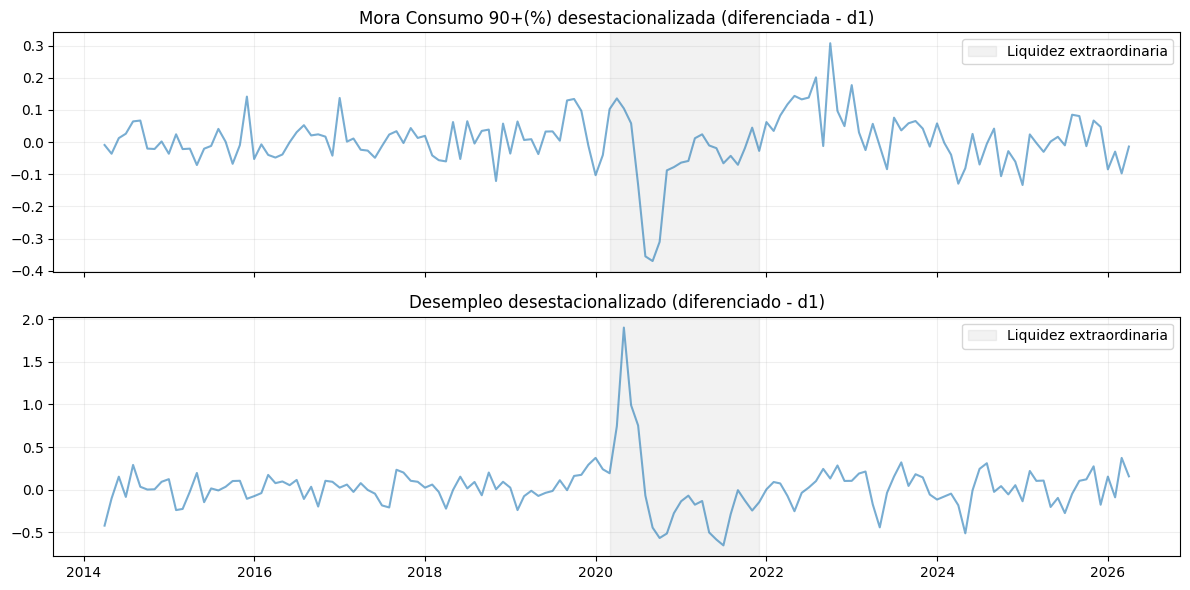

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Panel 1: Mora
axes[0].plot(mora_pivot["fecha2"], mora_pivot["Consumo_sa_d1"], alpha=0.6)
axes[0].set_title("Mora Consumo 90+(%) desestacionalizada (diferenciada - d1)")
axes[0].axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-12-01"),
    alpha=0.1, color="gray", label="Liquidez extraordinaria"
)
axes[0].legend()  # ← necesario para que aparezca el label del axvspan
axes[0].grid(alpha=0.2)

# Panel 2: Desempleo
axes[1].plot(mora_pivot["fecha2"], mora_pivot["desempleo_sa_d1"], alpha=0.6)
axes[1].set_title("Desempleo desestacionalizado (diferenciado - d1)")
axes[1].axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-12-01"),
    alpha=0.1, color="gray", label="Liquidez extraordinaria"
)
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Al evaluar ambas series desestacionalizadas y diferenciadas, podemos concluir que ambas son estacionarias. El siguiente paso es evaluar su cointegración.

# 5 - Cointegración

Para determinar si existe cointegración se usará el test "Engle-Granger", pero antes de ello se determinará el rezago óptimo para este test.

In [17]:
# Período pandemia a excluir (inversión de la relación por liquidez extraordinaria)
PAND_INI = pd.Timestamp("2020-03-01")
PAND_FIN = pd.Timestamp("2021-12-01")

In [18]:
# =============================================================================
# Selección sistemática del lag por BIC (independiente del test de cointegración)
# =============================================================================
LAGS_CANDIDATOS = range(0, 15)   # 0 a 14 meses

resultados_lag = []
for L in LAGS_CANDIDATOS:
    b = (mora_pivot[["fecha2", "Consumo_sa", "desempleo_sa"]]
         .dropna(subset=["Consumo_sa", "desempleo_sa"])
         .sort_values("fecha2").reset_index(drop=True).copy())
    b["dlag"]  = b["desempleo_sa"].shift(L)
    b["fpred"] = b["fecha2"] - pd.DateOffset(months=L)
    en_pand = (b["fecha2"].between(PAND_INI, PAND_FIN)) | (b["fpred"].between(PAND_INI, PAND_FIN))
    cl = b[~en_pand].dropna(subset=["dlag"]).reset_index(drop=True)

    mod = sm.OLS(cl["Consumo_sa"], sm.add_constant(cl["dlag"])).fit()
    resultados_lag.append({"lag": L, "n_obs": int(mod.nobs),
                           "bic": mod.bic, "aic": mod.aic,
                           "r2": mod.rsquared, "beta": mod.params.iloc[1]})

tabla_lag = pd.DataFrame(resultados_lag)
lag_optimo = int(tabla_lag.loc[tabla_lag["bic"].idxmin(), "lag"])

print("Selección de lag por BIC (menor = mejor):\n")
print(tabla_lag.round(3).to_string(index=False))
print(f"\n→ Lag óptimo por BIC: {lag_optimo} meses")

Selección de lag por BIC (menor = mejor):

 lag  n_obs     bic     aic    r2  beta
   0    124  19.403  13.762 0.450 0.238
   1    122   1.438  -4.170 0.492 0.242
   2    120 -16.794 -22.369 0.533 0.245
   3    118 -32.799 -38.340 0.566 0.244
   4    116 -47.623 -53.130 0.599 0.244
   5    114 -59.659 -65.132 0.629 0.245
   6    112 -72.851 -78.288 0.667 0.251
   7    110 -82.746 -88.147 0.698 0.256
   8    108 -84.514 -89.879 0.710 0.258
   9    106 -83.814 -89.141 0.715 0.259
  10    104 -78.445 -83.734 0.710 0.260
  11    102 -70.977 -76.227 0.697 0.259
  12    100 -61.349 -66.559 0.675 0.257
  13     98 -52.486 -57.656 0.650 0.253
  14     96 -43.300 -48.429 0.618 0.247

→ Lag óptimo por BIC: 8 meses


Una vez establecido el lag óptimo, se procederá a generar una serie omitiendo el periodo de pandemia para evitar los shocks observados en ambas series.

In [19]:
# =============================================================================
# Muestra limpia: rezago calendario-correcto, excluyendo pandemia
# (usa el lag óptimo seleccionado por BIC)
# =============================================================================
base = (mora_pivot[["fecha2", "Consumo_sa", "desempleo_sa"]]
        .dropna(subset=["Consumo_sa", "desempleo_sa"])
        .sort_values("fecha2").reset_index(drop=True).copy())

base["dlag"]  = base["desempleo_sa"].shift(lag_optimo)
base["fpred"] = base["fecha2"] - pd.DateOffset(months=lag_optimo)

en_pand = (base["fecha2"].between(PAND_INI, PAND_FIN)) | (base["fpred"].between(PAND_INI, PAND_FIN))
clean_opt = base[~en_pand].dropna(subset=["dlag"]).reset_index(drop=True)

print(f"Lag usado:            {lag_optimo} meses")
print(f"Obs. totales:         {len(base)}")
print(f"Obs. tras limpieza:   {len(clean_opt)}")
print(f"Rango: {clean_opt['fecha2'].min():%Y-%m} a {clean_opt['fecha2'].max():%Y-%m}")
print(f"Salto máximo unión:   {int(clean_opt['fecha2'].diff().dt.days.max()/30)} meses aprox.")

Lag usado:            8 meses
Obs. totales:         146
Obs. tras limpieza:   108
Rango: 2014-11 a 2026-04
Salto máximo unión:   31 meses aprox.


El siguiente paso es aplicar el test Engle-Granger para determinar si existe cointegración entre ambas series.

In [20]:
# =============================================================================
# Engle-Granger (caso base, sin modelar quiebre) + elasticidad de largo plazo (HAC)
# =============================================================================
y = clean_opt["Consumo_sa"].values
x = clean_opt["dlag"].values

eg_stat, eg_p, eg_crit = coint(y, x)   # coint() usa críticos MacKinnon correctos
print("="*60)
print(f"ENGLE-GRANGER   (mora_t ~ desempleo_(t-{lag_optimo}))")
print("="*60)
print(f"Estadístico:          {eg_stat:.4f}")
print(f"p-value (MacKinnon):  {eg_p:.4f}")
print(f"Críticos 1/5/10%:     {eg_crit[0]:.3f} / {eg_crit[1]:.3f} / {eg_crit[2]:.3f}")
print(f"Conclusión: {'Cointegradas ✅' if eg_p < 0.05 else 'No cointegradas (sin modelar quiebre) ❌'}")

ols_hac = sm.OLS(y, sm.add_constant(x)).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
beta, ic = ols_hac.params[1], ols_hac.conf_int()[1]
print(f"\nElasticidad de largo plazo (HAC, muestra completa sin pandemia):")
print(f"  β = {beta:.3f} pp de mora por cada +1 pp de desempleo")
print(f"  IC95% = [{ic[0]:.3f}, {ic[1]:.3f}]   p = {ols_hac.pvalues[1]:.4f}")

ENGLE-GRANGER   (mora_t ~ desempleo_(t-8))
Estadístico:          -1.8991
p-value (MacKinnon):  0.5805
Críticos 1/5/10%:     -4.002 / -3.394 / -3.084
Conclusión: No cointegradas (sin modelar quiebre) ❌

Elasticidad de largo plazo (HAC, muestra completa sin pandemia):
  β = 0.258 pp de mora por cada +1 pp de desempleo
  IC95% = [0.181, 0.336]   p = 0.0000


Si bien mediante el test Engle-Granger se concluye que las series no presentan cointegración, esto debe tomarse con precaución, ya que pudieron existir cambios estructurales en ambas series producto de los shocks de la pandemia. Por esta razón, el test de Gregory-Hansen es el más adecuado para evaluar la existencia de cointegración.

In [21]:
# =============================================================================
# Gregory-Hansen (1996): cointegración permitiendo UN quiebre estructural
# =============================================================================
def gregory_hansen(y, x, model="C", trim=0.15):
    y = np.asarray(y, float); x = np.asarray(x, float)
    n = len(y); t = np.arange(1, n + 1)
    lo, hi = int(np.floor(n * trim)), int(np.ceil(n * (1 - trim)))
    stats = []
    for k in range(lo, hi):
        phi = (t > k).astype(float)
        if   model == "C":   X = np.column_stack([np.ones(n), phi, x])
        elif model == "CT":  X = np.column_stack([np.ones(n), phi, t, x])
        elif model == "CS":  X = np.column_stack([np.ones(n), phi, x, x * phi])
        else: raise ValueError("model debe ser 'C', 'CT' o 'CS'")
        resid = sm.OLS(y, X).fit().resid
        stats.append(adfuller(resid, regression="n", autolag="AIC")[0])  # solo el t-stat
    stats = np.array(stats); i = int(stats.argmin())
    return stats[i], lo + i, stats

# Valores críticos Gregory-Hansen (1996), Tabla 1, m=1 regresor
# VERIFICAR contra el paper original al publicar
GH_CRIT = {"C":  {"1%": -5.13, "5%": -4.61, "10%": -4.34},
           "CT": {"1%": -5.45, "5%": -4.99, "10%": -4.72},
           "CS": {"1%": -5.47, "5%": -4.95, "10%": -4.68}}

In [22]:
# =============================================================================
# Gregory-Hansen UNA VEZ en el lag seleccionado (no se busca entre lags)
# =============================================================================
b = (mora_pivot[["fecha2", "Consumo_sa", "desempleo_sa"]]
     .dropna(subset=["Consumo_sa", "desempleo_sa"])
     .sort_values("fecha2").reset_index(drop=True).copy())
b["dlag"] = b["desempleo_sa"].shift(lag_optimo)
b["fpred"] = b["fecha2"] - pd.DateOffset(months=lag_optimo)
en_pand = lambda f: (f >= PAND_INI) & (f <= PAND_FIN)
clean_opt = b[~en_pand(b["fecha2"]) & ~en_pand(b["fpred"])].dropna(subset=["dlag"]).reset_index(drop=True)



print("="*64)
print(f"GREGORY-HANSEN  |  lag óptimo (BIC) = {lag_optimo}  |  n = {len(clean_opt)}")
print("="*64)
for m in ["C", "CT", "CS"]:
    gh, pos, _ = gregory_hansen(clean_opt["Consumo_sa"], clean_opt["dlag"], model=m)
    c = GH_CRIT[m]
    veredicto = "Cointegradas con quiebre ✅" if gh < c["5%"] else "No se rechaza ❌"
    print(f"\nModelo {m:2s}:  GH = {gh:.3f}  |  quiebre = {clean_opt['fecha2'].iloc[pos]:%Y-%m}")
    print(f"          Críticos 1/5/10%: {c['1%']} / {c['5%']} / {c['10%']}  →  {veredicto} (5%)")

GREGORY-HANSEN  |  lag óptimo (BIC) = 8  |  n = 108

Modelo C :  GH = -6.239  |  quiebre = 2024-04
          Críticos 1/5/10%: -5.13 / -4.61 / -4.34  →  Cointegradas con quiebre ✅ (5%)

Modelo CT:  GH = -6.055  |  quiebre = 2024-04
          Críticos 1/5/10%: -5.45 / -4.99 / -4.72  →  Cointegradas con quiebre ✅ (5%)

Modelo CS:  GH = -6.239  |  quiebre = 2024-06
          Críticos 1/5/10%: -5.47 / -4.95 / -4.68  →  Cointegradas con quiebre ✅ (5%)


Se observa que las tres versiones del test Gregory-Hansen nos hacen concluir que ambas series están cointegradas y reconocen la existencia de un quiebre, pero ¿cuál de las versiones de este test es más representativa para nuestras series? Para responder esto último es importante plantearnos qué series estamos analizando: ya que ambas series están desestacionalizadas y tienen una tendencia, el test más adecuado es el C.
Dado lo anterior, se concluye que ambas series están cointegradas y que además se produjo un quiebre en abril de 2024.
El siguiente paso es determinar las elasticidades de ambas series, pre y post quiebre.

Las tres versiones del test de Gregory-Hansen (C, C/T y C/S) coinciden en rechazar la no cointegración e identifican un quiebre estructural a mediados de 2024. Esto confirma que las series comparten una relación de equilibrio de largo plazo una vez que se permite un cambio estructural en ella.

Entre las tres especificaciones se adopta como referencia el modelo **C (cambio de nivel)**, por ser el más parsimonioso: supone que el quiebre afecta el nivel de la relación, pero no su pendiente. Esta elección se contrasta en el siguiente paso, donde se estiman las elasticidades de largo plazo en cada régimen: si la pendiente resulta estable entre el período pre y post quiebre, se confirma que el modelo C es el adecuado.

El siguiente paso es, entonces, estimar las elasticidades pre y post quiebre.

In [23]:
# =============================================================================
# Elasticidades por régimen (pre vs post quiebre GH)
# =============================================================================
FECHA_QUIEBRE = pd.Timestamp("2024-04-01")   # quiebre del modelo C, lag 8

df_reg = clean_opt.copy()   # ya tiene Consumo_sa y dlag (desempleo lag 8), sin pandemia
df_reg["regimen"] = np.where(df_reg["fecha2"] < FECHA_QUIEBRE, "pre", "post")

print("="*64)
print(f"ELASTICIDADES POR RÉGIMEN  (quiebre = {FECHA_QUIEBRE:%Y-%m}, lag 8)")
print("="*64)

for reg in ["pre", "post"]:
    sub = df_reg[df_reg["regimen"] == reg]
    yv = sub["Consumo_sa"].values
    xv = sub["dlag"].values
    mod = sm.OLS(yv, sm.add_constant(xv)).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    beta = mod.params[1]
    ic = mod.conf_int()[1]
    print(f"\nRégimen {reg.upper():4s}  (n = {len(sub)}, {sub['fecha2'].min():%Y-%m} a {sub['fecha2'].max():%Y-%m})")
    print(f"  β = {beta:.3f} pp mora por +1 pp desempleo")
    print(f"  IC95% = [{ic[0]:.3f}, {ic[1]:.3f}]   p = {mod.pvalues[1]:.4f}   R² = {mod.rsquared:.3f}")

# Modelo conjunto con interacción: test formal de si β cambió entre regímenes
df_reg["post"] = (df_reg["regimen"] == "post").astype(int)
df_reg["x_post"] = df_reg["dlag"] * df_reg["post"]
Xint = sm.add_constant(df_reg[["dlag", "post", "x_post"]])
mint = sm.OLS(df_reg["Consumo_sa"], Xint).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print("\n" + "="*64)
print("TEST FORMAL: ¿cambió la pendiente entre regímenes? (término x_post)")
print("="*64)
print(f"  Coef. interacción (x_post) = {mint.params['x_post']:.3f}")
print(f"  p-value = {mint.pvalues['x_post']:.4f}")
print(f"  → {'La pendiente SÍ cambió significativamente' if mint.pvalues['x_post'] < 0.05 else 'No hay evidencia de cambio de pendiente'}")

ELASTICIDADES POR RÉGIMEN  (quiebre = 2024-04, lag 8)

Régimen PRE   (n = 83, 2014-11 a 2024-03)
  β = 0.370 pp mora por +1 pp desempleo
  IC95% = [0.313, 0.427]   p = 0.0000   R² = 0.793

Régimen POST  (n = 25, 2024-04 a 2026-04)
  β = 0.369 pp mora por +1 pp desempleo
  IC95% = [0.277, 0.460]   p = 0.0000   R² = 0.545

TEST FORMAL: ¿cambió la pendiente entre regímenes? (término x_post)
  Coef. interacción (x_post) = -0.002
  p-value = 0.9729
  → No hay evidencia de cambio de pendiente


El resultado de las elasticidades es bastante sólido: ambas elasticidades son prácticamente iguales y no hay evidencia de un cambio de pendiente. Lo que sí es conveniente observar es el R² del modelo post, el cual es menor al del modelo pre; esto podría explicarse por la menor cantidad de observaciones en el modelo post o por una variable no observada.

# 6 - Conclusiones

La principal conclusión es que el desempleo y la morosidad consumo 90+(%) están cointegrados, es decir, comparten una relación de equilibrio de largo plazo. Más específicamente, **en el largo plazo un aumento de 1 pp en el desempleo se asocia con un nivel de mora consumo 90+(%) 0.369 pp más alto**. Adicionalmente, el análisis identifica que el desempleo se relaciona con la morosidad con un rezago en torno a 8 meses, lo que respalda su uso como indicador de alerta temprana y permite a las gerencias de riesgo anticipar alzas de morosidad y ajustar sus políticas preventivamente.

Es importante precisar el alcance de estos dos resultados. El valor de 0.369 pp describe la relación estructural de **largo plazo**; no significa que un cambio en el desempleo afecte a la morosidad 8 meses después en exactamente 0.369 pp. Esa dinámica precisa del ajuste —en cuántos meses y a qué velocidad la mora converge a su nuevo equilibrio tras un cambio en el desempleo— se abordará en la Parte 2 de este estudio, mediante modelos diseñados para capturar esa trayectoria temporal.

Es importante no dejar pasar que durante la pandemia se produjeron shocks tanto en el desempleo, que tuvo un fuerte aumento, como en la morosidad 90+(%), la cual, pese al alto desempleo, tuvo una baja histórica. Esto obligó a ser muy estricto en el análisis EDA y a utilizar el test de Gregory-Hansen para detectar, además de la cointegración, un cambio de régimen ocurrido en abril de 2024. Este último resultado resulta particularmente interesante, ya que en una publicación anterior se detectó un cambio estructural en el empleo en febrero de 2024; si bien no es posible afirmar, sin realizar un análisis inferencial, que ambos eventos estén relacionados, no deja de llamar la atención la cercanía de ambas fechas.

